# 07 — Prepare Lane Segmentation Masks

**Goal:** Convert BDD100K lane polyline annotations into binary segmentation masks for joint training.

This notebook:
1. Loads BDD100K lane annotation JSON
2. Rasterises `poly2d` polylines (including Bezier curves) into binary masks
3. Saves masks as PNGs at 320×180 (¼ resolution to save GPU memory)
4. Visualises sample masks overlaid on images
5. Prints statistics

## BDD100K Lane Categories (all merged to binary foreground)
| Category | Merged To |
|---|---|
| lane/single white | foreground (1) |
| lane/single yellow | foreground (1) |
| lane/double white | foreground (1) |
| lane/double yellow | foreground (1) |
| lane/single other | foreground (1) |
| lane/double other | foreground (1) |
| lane/road curb | foreground (1) |
| lane/crosswalk | foreground (1) |

## 1 — Setup

In [8]:
!pip install -q opencv-python matplotlib tqdm pyyaml numpy

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os
import sys
import json
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────
ECOCAR_ROOT = "/content/drive/MyDrive/EcoCAR"
BDD_RAW_DIR = os.path.join(ECOCAR_ROOT, "datasets", "bdd100k_raw")
YOLO_DATASET_DIR = "/content/bdd100k_yolo"

# Output mask directories
TRAIN_MASKS_DIR = os.path.join(YOLO_DATASET_DIR, "masks", "train")
VAL_MASKS_DIR = os.path.join(YOLO_DATASET_DIR, "masks", "val")

# Mask resolution (1/4 of 1280×720)
MASK_WIDTH = 320
MASK_HEIGHT = 180

# Debug mode: set to small number for quick testing
DEBUG_LIMIT = None  # e.g., 100

if DEBUG_LIMIT:
    print(f"⚡ DEBUG MODE: {DEBUG_LIMIT} images")

print(f"Raw BDD dir:  {BDD_RAW_DIR}")
print(f"Dataset dir:  {YOLO_DATASET_DIR}")
print(f"Mask size:    {MASK_WIDTH}×{MASK_HEIGHT}")

Raw BDD dir:  /content/drive/MyDrive/EcoCAR/datasets/bdd100k_raw
Dataset dir:  /content/bdd100k_yolo
Mask size:    320×180


## 2 — Load Lane Utilities

In [11]:
# Try to import from src/, fallback to inline definitions
PROJECT_SRC = os.path.join(ECOCAR_ROOT, "project", "src")
if os.path.isdir(PROJECT_SRC):
    sys.path.insert(0, os.path.dirname(PROJECT_SRC))

try:
    from src.lane_utils import (
        BDD_LANE_CATEGORIES, render_lane_mask,
        convert_bdd_lanes_to_masks, print_lane_stats
    )
    print("✅ Imported from src.lane_utils")
except ImportError:
    print("⚠️ Using inline lane utilities")

    BDD_LANE_CATEGORIES = [
        "lane/crosswalk", "lane/double other", "lane/double white",
        "lane/double yellow", "lane/road curb", "lane/single other",
        "lane/single white", "lane/single yellow",
    ]
    LANE_CAT_TO_ID = {cat: 1 for cat in BDD_LANE_CATEGORIES}

    def _bezier_curve(p0, p1, p2, p3, num_points=30):
        points = []
        for i in range(num_points + 1):
            t = i / num_points
            mt = 1 - t
            x = mt**3*p0[0] + 3*mt**2*t*p1[0] + 3*mt*t**2*p2[0] + t**3*p3[0]
            y = mt**3*p0[1] + 3*mt**2*t*p1[1] + 3*mt*t**2*p2[1] + t**3*p3[1]
            points.append((int(round(x)), int(round(y))))
        return points

    def _poly2d_to_points(vertices, types, scale_x=1.0, scale_y=1.0):
        points = []
        i = 0
        n = len(vertices)
        while i < n:
            vx = vertices[i][0] * scale_x
            vy = vertices[i][1] * scale_y
            if i + 2 < n and i + 1 < len(types) and types[i + 1] == 'C':
                if i + 3 < n:
                    p0 = (vx, vy)
                    p1 = (vertices[i+1][0]*scale_x, vertices[i+1][1]*scale_y)
                    p2 = (vertices[i+2][0]*scale_x, vertices[i+2][1]*scale_y)
                    p3 = (vertices[i+3][0]*scale_x, vertices[i+3][1]*scale_y)
                    points.extend(_bezier_curve(p0, p1, p2, p3))
                    i += 4
                else:
                    points.append((int(round(vx)), int(round(vy))))
                    i += 1
            else:
                points.append((int(round(vx)), int(round(vy))))
                i += 1
        return points

    def render_lane_mask(labels, mask_width=320, mask_height=180,
                         img_width=1280, img_height=720, line_thickness=2):
        mask = np.zeros((mask_height, mask_width), dtype=np.uint8)
        sx, sy = mask_width/img_width, mask_height/img_height
        for label in labels:
            if label.get('category', '') not in LANE_CAT_TO_ID:
                continue
            for poly in (label.get('poly2d') or []):
                verts = poly.get('vertices', [])
                types = poly.get('types', 'L' * len(verts))
                if len(verts) < 2: continue
                pts = _poly2d_to_points(verts, types, sx, sy)
                if len(pts) >= 2:
                    cv2.polylines(mask, [np.array(pts, dtype=np.int32)],
                                  False, 255, line_thickness)
        return mask

    def convert_bdd_lanes_to_masks(json_path, output_mask_dir,
                                   mask_width=320, mask_height=180,
                                   img_width=1280, img_height=720,
                                   line_thickness=2, debug_limit=None):
        os.makedirs(output_mask_dir, exist_ok=True)
        with open(json_path, 'r') as f:
            data = json.load(f)
        if debug_limit: data = data[:debug_limit]
        stats = {'total_images': len(data), 'images_with_lanes': 0, 'total_lane_annotations': 0}
        for frame in tqdm(data, desc='Rendering masks'):
            name = frame.get('name', '')
            labels = frame.get('labels') or []
            lanes = [l for l in labels if l.get('category', '') in LANE_CAT_TO_ID]
            if lanes:
                stats['images_with_lanes'] += 1
                stats['total_lane_annotations'] += len(lanes)
            mask = render_lane_mask(lanes, mask_width, mask_height, img_width, img_height, line_thickness)
            cv2.imwrite(os.path.join(output_mask_dir, Path(name).stem + '.png'), mask)
        return stats

    def print_lane_stats(stats):
        print(f"\nTotal: {stats['total_images']:,} | With lanes: {stats['images_with_lanes']:,} | Annotations: {stats['total_lane_annotations']:,}")

✅ Imported from src.lane_utils


## 3 — Find Lane Annotation Files

In [12]:
# BDD100K lane annotations can live in different places depending on download
lane_search_paths = [
    # Separate lane download (newer format)
    os.path.join(BDD_RAW_DIR, "bdd100k", "labels", "lane", "polygons", "lane_train.json"),
    os.path.join(BDD_RAW_DIR, "bdd100k", "labels", "lane", "polygons", "lane_val.json"),
    # Older format: lane marks in main labels
    os.path.join(BDD_RAW_DIR, "bdd100k", "labels", "bdd100k_labels_images_train.json"),
    os.path.join(BDD_RAW_DIR, "bdd100k", "labels", "bdd100k_labels_images_val.json"),
    # Direct paths
    os.path.join(BDD_RAW_DIR, "labels", "lane", "polygons", "lane_train.json"),
    os.path.join(BDD_RAW_DIR, "labels", "lane", "polygons", "lane_val.json"),
    os.path.join(BDD_RAW_DIR, "labels", "bdd100k_labels_images_train.json"),
    os.path.join(BDD_RAW_DIR, "labels", "bdd100k_labels_images_val.json"),
]

TRAIN_LANE_JSON = None
VAL_LANE_JSON = None

for p in lane_search_paths:
    if os.path.isfile(p):
        if 'train' in os.path.basename(p):
            TRAIN_LANE_JSON = p
        elif 'val' in os.path.basename(p):
            VAL_LANE_JSON = p

print(f"Train lane JSON: {TRAIN_LANE_JSON}")
print(f"Val lane JSON:   {VAL_LANE_JSON}")

if not TRAIN_LANE_JSON:
    print("\n❌ Lane annotation JSON not found!")
    print("   Searching for any JSON with lane content...")
    all_json = glob.glob(os.path.join(BDD_RAW_DIR, '**', '*.json'), recursive=True)
    for jf in all_json[:15]:
        print(f"   {jf}")
    print("\n   ↑ Set TRAIN_LANE_JSON and VAL_LANE_JSON manually above.")

Train lane JSON: /content/drive/MyDrive/EcoCAR/datasets/bdd100k_raw/labels/bdd100k_labels_images_train.json
Val lane JSON:   /content/drive/MyDrive/EcoCAR/datasets/bdd100k_raw/labels/bdd100k_labels_images_val.json


## 4 — Preview Lane Annotations

In [13]:
if TRAIN_LANE_JSON:
    with open(TRAIN_LANE_JSON, 'r') as f:
        lane_data = json.load(f)

    print(f"Total frames: {len(lane_data)}")
    print(f"First entry keys: {list(lane_data[0].keys())}")

    # Count lane categories
    cat_counts = {}
    for frame in lane_data[:2000]:
        for label in (frame.get('labels') or []):
            cat = label.get('category', '')
            if 'lane' in cat.lower():
                cat_counts[cat] = cat_counts.get(cat, 0) + 1

    print(f"\nLane categories (first 2000 frames):")
    for cat, count in sorted(cat_counts.items(), key=lambda x: -x[1]):
        print(f"  {cat}: {count}")

Total frames: 16942
First entry keys: ['name', 'labels']

Lane categories (first 2000 frames):
  lane/single white: 7135
  lane/crosswalk: 3155
  lane/road curb: 3094
  lane/double yellow: 952
  lane/single yellow: 589
  lane/double white: 129
  lane/single other: 3


## 5 — Render Lane Masks

In [14]:
# Convert train lane annotations → masks
if TRAIN_LANE_JSON:
    print("\n" + "="*50)
    print(" Rendering TRAIN lane masks")
    print("="*50)

    train_stats = convert_bdd_lanes_to_masks(
        json_path=TRAIN_LANE_JSON,
        output_mask_dir=TRAIN_MASKS_DIR,
        mask_width=MASK_WIDTH,
        mask_height=MASK_HEIGHT,
        debug_limit=DEBUG_LIMIT,
    )
    print_lane_stats(train_stats)
else:
    print("❌ No train lane JSON found")


 Rendering TRAIN lane masks


Rendering lane masks: 100%|██████████| 16942/16942 [00:07<00:00, 2343.71it/s]



 Lane Mask Statistics
 Total images:          16,942
 Images with lanes:     16,089
 Lane coverage:         95.0%
 Total lane annotations:127,953
 Avg lanes per image:   8.0


In [15]:
# Convert val lane annotations → masks
if VAL_LANE_JSON:
    print("\n" + "="*50)
    print(" Rendering VAL lane masks")
    print("="*50)

    val_stats = convert_bdd_lanes_to_masks(
        json_path=VAL_LANE_JSON,
        output_mask_dir=VAL_MASKS_DIR,
        mask_width=MASK_WIDTH,
        mask_height=MASK_HEIGHT,
        debug_limit=DEBUG_LIMIT,
    )
    print_lane_stats(val_stats)
else:
    print("❌ No val lane JSON found")


 Rendering VAL lane masks


Rendering lane masks: 100%|██████████| 2990/2990 [00:02<00:00, 1297.46it/s]



 Lane Mask Statistics
 Total images:          2,990
 Images with lanes:     2,857
 Lane coverage:         95.6%
 Total lane annotations:22,903
 Avg lanes per image:   8.0


## 6 — Visualise Sample Masks

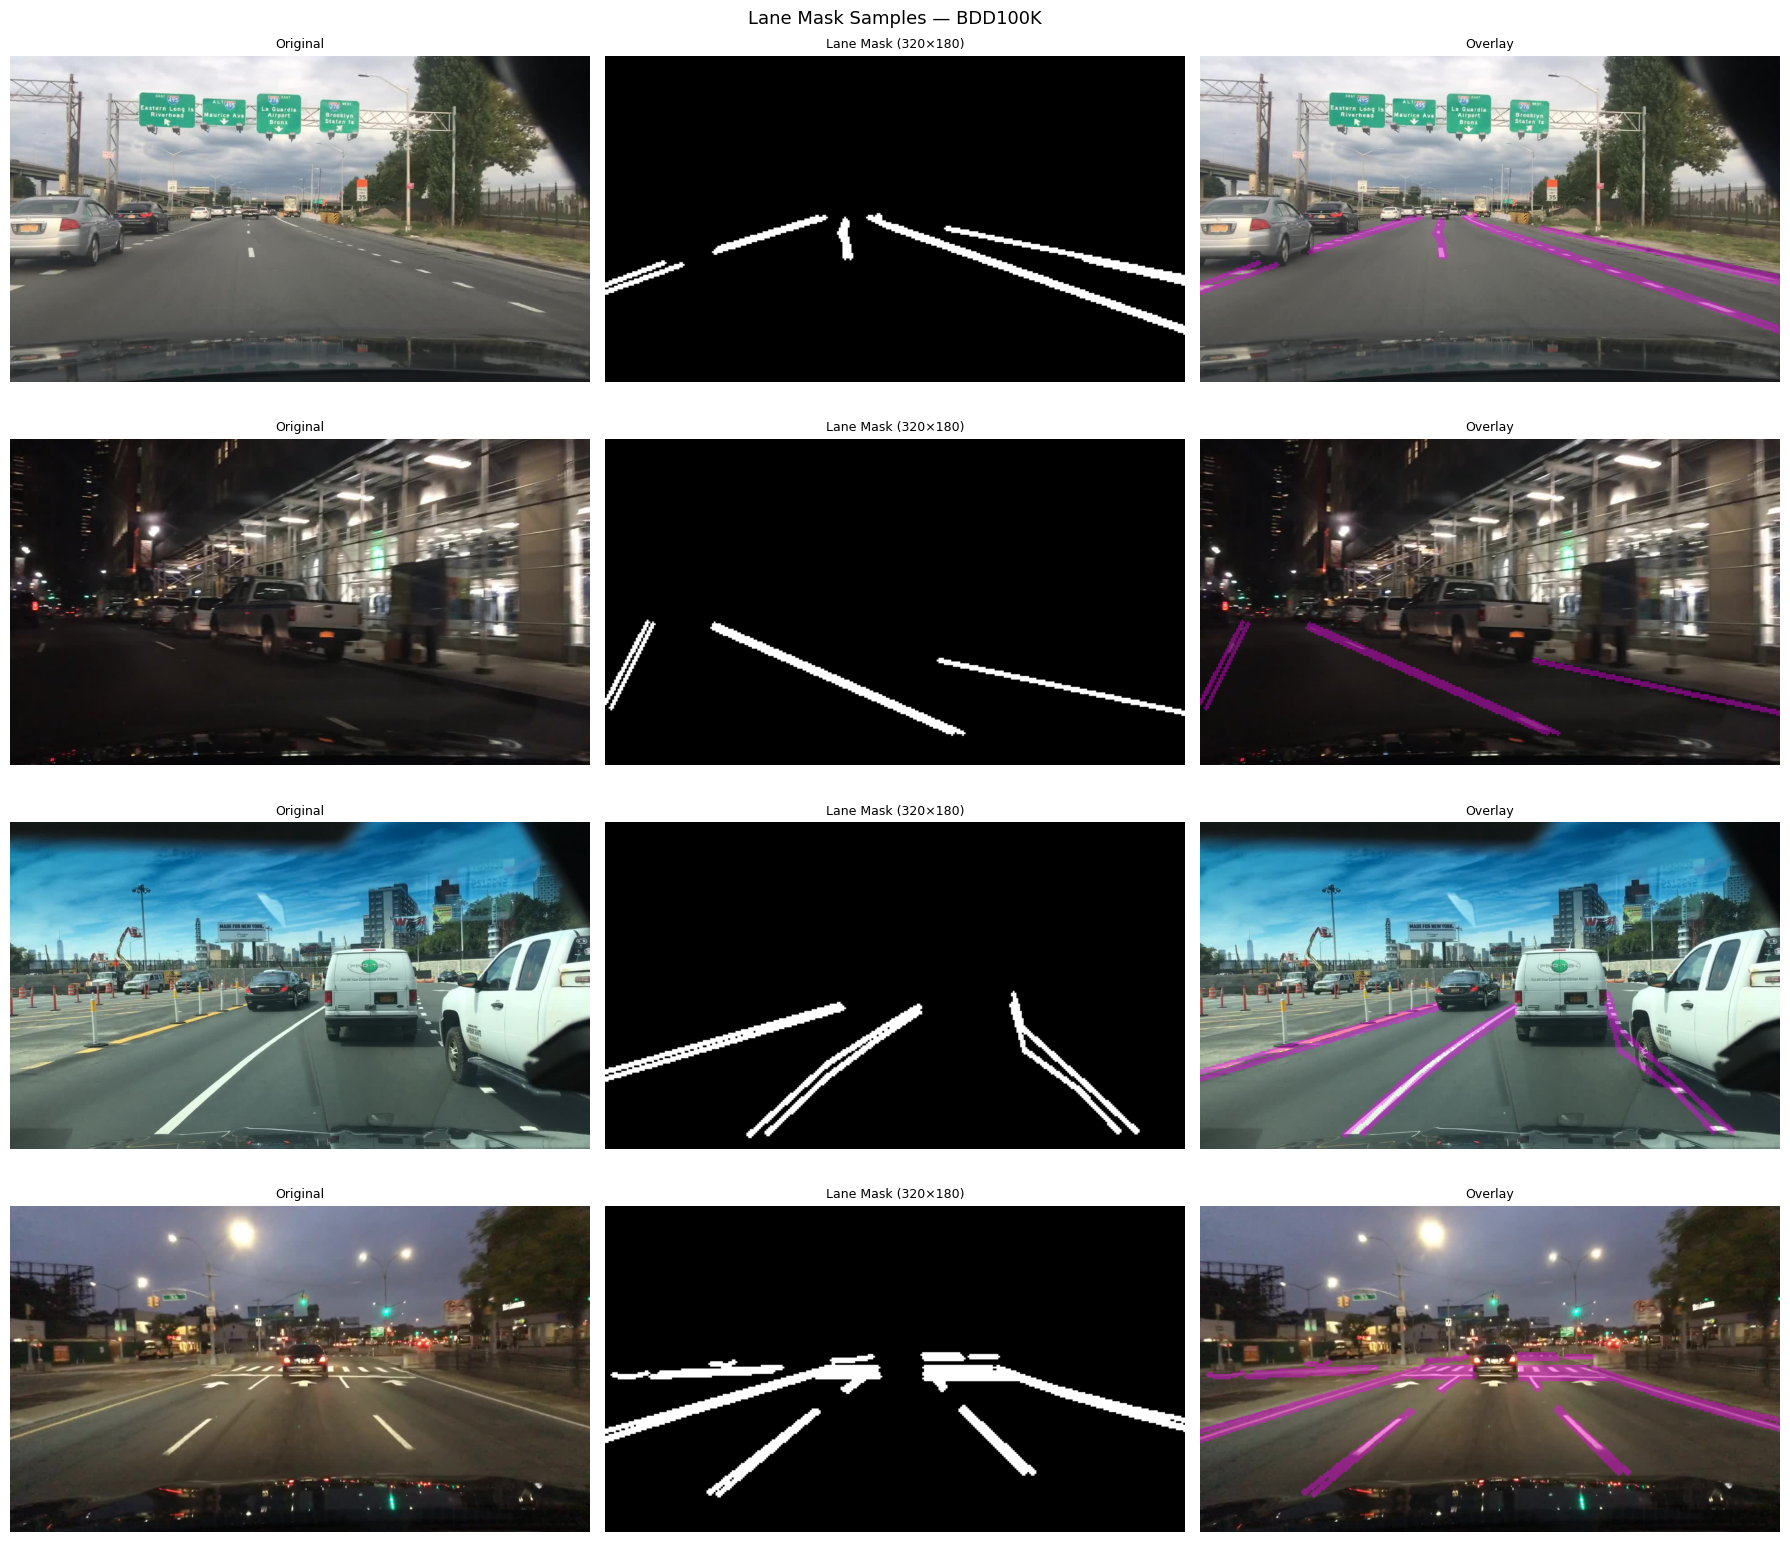

In [18]:
import random

train_images_dir = os.path.join(YOLO_DATASET_DIR, 'images', 'train')

# Get mask files that have corresponding images
mask_files = sorted(os.listdir(TRAIN_MASKS_DIR))[:1000]
valid_samples = []
for mf in mask_files:
    stem = os.path.splitext(mf)[0]
    for ext in ['.jpg', '.png', '.jpeg']:
        img_path = os.path.join(train_images_dir, stem + ext)
        if os.path.isfile(img_path):
            valid_samples.append((img_path, os.path.join(TRAIN_MASKS_DIR, mf)))
            break

# Pick random samples with non-empty masks
show_samples = []
random.shuffle(valid_samples)
for img_path, mask_path in valid_samples:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is not None and mask.max() > 0:
        show_samples.append((img_path, mask_path))
    if len(show_samples) >= 4:
        break

fig, axes = plt.subplots(len(show_samples), 3, figsize=(18, 4 * len(show_samples)))
if len(show_samples) == 1:
    axes = axes[np.newaxis, :]

for i, (img_path, mask_path) in enumerate(show_samples):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Overlay mask on image
    mask_resized = cv2.resize(mask, (img.shape[1], img.shape[0]),
                              interpolation=cv2.INTER_NEAREST)
    overlay = img_rgb.copy()
    overlay[mask_resized > 128] = [255, 0, 255]  # magenta for lanes
    blended = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)

    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title('Original', fontsize=9)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title(f'Lane Mask ({MASK_WIDTH}×{MASK_HEIGHT})', fontsize=9)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(blended)
    axes[i, 2].set_title('Overlay', fontsize=9)
    axes[i, 2].axis('off')

plt.suptitle('Lane Mask Samples — BDD100K', fontsize=13)
plt.tight_layout()
plt.show()

## 7 — Verify Mask Coverage

In [19]:
# Check that masks exist for images that have detection labels
train_labels_dir = os.path.join(YOLO_DATASET_DIR, 'labels', 'train')

label_stems = set(os.path.splitext(f)[0] for f in os.listdir(train_labels_dir) if f.endswith('.txt'))
mask_stems = set(os.path.splitext(f)[0] for f in os.listdir(TRAIN_MASKS_DIR) if f.endswith('.png'))

both = label_stems & mask_stems
labels_only = label_stems - mask_stems
masks_only = mask_stems - label_stems

print(f"\n{'='*40}")
print(f" Coverage Check (train)")
print(f"{'='*40}")
print(f" Detection labels:    {len(label_stems):,}")
print(f" Lane masks:          {len(mask_stems):,}")
print(f" Both (usable):       {len(both):,}")
print(f" Labels only:         {len(labels_only):,}")
print(f" Masks only:          {len(masks_only):,}")
print(f"{'='*40}")

if len(both) > 0:
    print(f"\n✅ {len(both):,} images ready for joint training!")
else:
    print("\n⚠️ No overlap found. Check paths.")


 Coverage Check (train)
 Detection labels:    174
 Lane masks:          16,942
 Both (usable):       174
 Labels only:         0
 Masks only:          16,768

✅ 174 images ready for joint training!


In [20]:
print("\n" + "="*60)
print(" LANE MASK PREPARATION — COMPLETE")
print("="*60)
print(f" Train masks: {TRAIN_MASKS_DIR}")
print(f" Val masks:   {VAL_MASKS_DIR}")
print(f" Mask size:   {MASK_WIDTH}×{MASK_HEIGHT}")
print("="*60)
print("\n🎯 Proceed to notebook 08 for joint training!")


 LANE MASK PREPARATION — COMPLETE
 Train masks: /content/bdd100k_yolo/masks/train
 Val masks:   /content/bdd100k_yolo/masks/val
 Mask size:   320×180

🎯 Proceed to notebook 08 for joint training!


In [22]:
%cd /content
!tar -cf masks.tar bdd100k_yolo/masks
!cp masks.tar /content/drive/MyDrive/EcoCAR/datasets/bdd100k_yolo/

/content
